[[0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0], [0, 0, 1, 1], [0, 1, 0, 0], [0, 1, 0, 1], [0, 1, 1, 0], [0, 1, 1, 1], [1, 0, 0, 0], [1, 0, 0, 1], [1, 0, 1, 0], [1, 0, 1, 1], [1, 1, 0, 0], [1, 1, 0, 1], [1, 1, 1, 0], [1, 1, 1, 1]]
[[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)], [np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1)], [np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0)], [np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1)], [np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1)], [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0)], [np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1)], [np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)], [np.int64(1), np.int64(0), np.

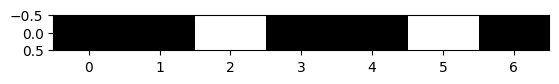


シンドローム
[1 0 1]


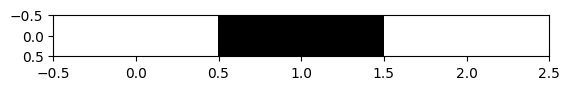

In [1]:
import numpy as np
import matplotlib.pyplot as plt

G = np.array([
        [1, 0, 0, 0, 0, 1, 1],
        [0, 1, 0, 0, 1, 0, 1],
        [0, 0, 1, 0, 1, 1, 0],
        [0, 0, 0, 1, 1, 1, 1]
    ])

H = np.array([
        [1, 0, 1, 0, 1, 0, 1],
        [0, 1, 1, 0, 0, 1, 1],
        [0, 0, 0, 1, 1, 1, 1]
        ])

N = np.arange(0,16)

R = []
for i in N:
    tmp = ('{:04b}'.format(i))
    tmp2 = list(tmp)
    for j in range(len(tmp2)):
        tmp2[j] = int(tmp2[j])
    R.append(list(tmp2))

print(R)

R2 = []
for i in R:
    tmp = np.array(i)
    tmp2 = np.dot(tmp,G)%2
    R2.append(list(tmp2))
    
print(R2)
print("")

print("3番目のベクトル([0, 0, 1, 0, 1, 1, 0])を送信符号語に選択")
print(R2[2:3][0])

import random
x = random.randint(0,6)

print("")
print("xビット目に誤りを生成")
if R2[2:3][0][x] == 0:
    (R2[2:3][0][x]) = 1 
else:
    (R2[2:3][0][x]) = 0
    
print(R2[2:3][0])
 
tmp2 = np.dot(R2[2:3][0],H.transpose())%2

print("")
print("計算結果")
print(tmp2)

print("")    
print("誤りベクトル、シンドローム")
print("[0,0,0,0,0,0,0] [0,0,0]")
print("[1,0,0,0,0,0,0] [1,0,0]")
print("[0,1,0,0,0,0,0] [0,1,0]")
print("[0,0,1,0,0,0,0] [1,1,0]")
print("[0,0,0,1,0,0,0] [0,0,1]")
print("[0,0,0,0,1,0,0] [1,0,1]")
print("[0,0,0,0,0,1,0] [0,1,1]")
print("[0,0,0,0,0,0,1] [1,1,1]")
    
print("")
print("送信符号語")

tmp4 = []
for i in R2[2:3][0]:
    tmp4.append(i*255)   
print(R2[2:3][0])
img_gray = np.array([tmp4], dtype = np.uint8)
plt.imshow(img_gray, cmap = 'gray', vmin = 0, vmax = 128, interpolation = 'none', aspect=0.5)
plt.show()

print("")
print("シンドローム")

tmp3 = []
for i in tmp2:
    tmp3.append(i*255)   
print(tmp2)

img_gray = np.array([tmp3], dtype = np.uint8)
plt.imshow(img_gray, cmap = 'gray', vmin = 0, vmax = 128, interpolation = 'none', aspect=0.25)
plt.show()



Original codeword: [1 0 1 0 1 0 1]
Codeword with error: [1 0 1 1 1 0 1]
Syndrome: [0 0 1]


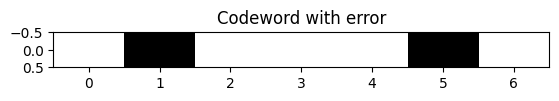

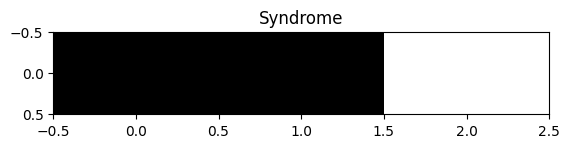

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 生成行列 G
G = np.array([
    [1, 0, 0, 0, 0, 1, 1],
    [0, 1, 0, 0, 1, 0, 1],
    [0, 0, 1, 0, 1, 1, 0],
    [0, 0, 0, 1, 1, 1, 1]
])

# 検査行列 H
H = np.array([
    [1, 0, 1, 0, 1, 0, 1],
    [0, 1, 1, 0, 0, 1, 1],
    [0, 0, 0, 1, 1, 1, 1]
])

def generate_codewords(data_bits):
    codewords = []
    for bits in data_bits:
        codeword = np.dot(bits, G) % 2
        codewords.append(codeword)
    return codewords

def calculate_syndrome(received_codeword):
    return np.dot(received_codeword, H.transpose()) % 2

def main(data_bits, error_bit_index):

    if len(data_bits) != 4:
        print("Error: The data bits must be a 4-bit binary number.")
        return
    
    if error_bit_index < 0 or error_bit_index > 6:
        print("Error: The error bit index must be between 0 and 6.")
        return

    # 符号語の生成
    codeword = generate_codewords([data_bits])[0]

    print("Original codeword:", codeword)
    
    # 誤りを生成
    codeword[error_bit_index] = 1 if codeword[error_bit_index] == 0 else 0

    print("Codeword with error:", codeword)

    # シンドロームの計算
    syndrome = calculate_syndrome(codeword)

    print("Syndrome:", syndrome)

    # Matplotlibで表示
    def plot_binary_array(arr, title):
        img_data = [i * 255 for i in arr]
        img_gray = np.array([img_data], dtype=np.uint8)
        plt.imshow(img_gray, cmap='gray', vmin=0, vmax=255, interpolation='none', aspect=0.5)
        plt.title(title)
        plt.show()

    plot_binary_array(codeword, "Codeword with error")
    plot_binary_array(syndrome, "Syndrome")

if __name__ == "__main__":
    # ここで4ビットのデータと誤りの位置を指定
    data_bits = [1, 0, 1, 0]
    error_bit_index = 3
    main(data_bits, error_bit_index)
